# Thouless charge pump — AAH quasicrystal

The Aubry-André-Harper model with the phase $\phi$ as the adiabatic pump parameter:

$$H(\phi) = -t \sum_{\langle i,j\rangle} c_i^\dagger c_j
            + V \sum_i \cos(2\pi b\,i + \phi)\,n_i,
\qquad b = \tfrac{1+\sqrt{5}}{2}$$

As $\phi$ sweeps one full cycle $[0, 2\pi)$ the quasiperiodic potential shifts
rigidly, transporting charge by an integer number of lattice spacings — the
**Chern number** of the occupied band.

**Wannier centre**: the mean position of all occupied states
$$W(\phi) = \frac{1}{N_e} \operatorname{Tr}[P(\phi)\,\hat x]$$
tracks the charge centre of mass.  Over one pump cycle $\Delta W = W(2\pi) - W(0) = C$.

**Berry curvature integral** (no $U$ needed):
$$C = \frac{i}{2\pi}\int_0^{2\pi} \operatorname{Tr}\!\left[P(\phi)\,[\dot P(\phi),\hat x]\right] d\phi$$

$P(\phi)$ is computed at each $\phi$ step via McWeeny purification.

In [60]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../src/TensorBinding.jl")
using .TensorBinding

---
## 1. System parameters

`L = 5` gives $N = 32$ sites.  We work in the **extended phase** ($V < 2t$) where
the ground state is gapped at half-filling due to the quasiperiodic structure.
The analytic scale estimate $(t + V) \times 1.2$ is set at construction to avoid
a DMRG call inside every `mcweeny_purify`.

In [70]:
L_pump   = 5
N_pump   = 2^L_pump          # 32 sites
t_pump   = 1.0
V_pump   = 2.0               # quasiperiodic amplitude (< 2t → extended/gapped)
b_pump   = 1/3               # modulation periodicity; tune to get different Chern numbers
ϵF_pump  = -1.3              # Fermi energy targeting the lower third of the spectrum ≈ [-4, 4]
Ne_pump  = N_pump ÷ 2        # half-filling reference

# φ sweeps [0, 2π) in Nt evenly-spaced steps
Nt_pump  = 200
T_pump   = 2π
dt_pump  = T_pump / Nt_pump
phi_vals = [k * dt_pump for k in 0:(Nt_pump - 1)]

scale_pump = (2t_pump + V_pump) * 1.2

# Build once to obtain shared site indices; all H_k reuse them via ref_sites
_H_ref     = TensorBinding.get_Hamiltonian(
    "aah", (V=V_pump, phi=0.0, t=t_pump, b=b_pump); L=L_pump, scale=scale_pump)
pump_sites = _H_ref.sites

# Factory: b is passed inside the params NamedTuple so it reaches HAAH via mparam_dict
H_aah_of_phi(phi) = TensorBinding.get_Hamiltonian(
    "aah", (V=V_pump, phi=phi, t=t_pump, b=b_pump); L=L_pump, scale=scale_pump,
    ref_sites=pump_sites)

xfunc(i, N) = Float64(i)
H0       = H_aah_of_phi(0.0)
x_op     = TensorBinding.get_pump_xop(H0.L, H0.sites, xfunc; quenched=false)
r_center = N_pump ÷ 2        # bulk central site for M1Q marker

println(H0)
println("b = $b_pump,  V = $V_pump,  ϵF = $ϵF_pump,  Nt = $Nt_pump,  r_c = $r_center")

TBHamiltonian | L=5, N=32, scale=4.8, maxlinkdim=5 | geometry: 32 sites, 1D | no Tn cache
b = 0.3333333333333333,  V = 2.0,  ϵF = -1.3,  Nt = 200,  r_c = 16


---
## 2. Wannier centre trajectory

At each phase step $\phi_k$ we:
1. Build $H(\phi_k)$ and compute $P(\phi_k)$ via McWeeny purification.
2. Store $P(\phi_k)$ in `P_array` for the Berry curvature integral.
3. Record $W(\phi_k) = \operatorname{Tr}[P\hat x] / N_e$.

In [71]:
maxdim_pump = 80
cutoff_pump = 1e-8

P_array = MPO[]
wannier  = Float64[]
npart    = Float64[]   # particle number check

for (k, phi) in enumerate(phi_vals)
    println("Step $k/$(Nt_pump): φ/π = $(round(phi/π; digits=3))")
    H_k = H_aah_of_phi(phi)
    P_k = TensorBinding.get_density(H_k; method=:mcweeny, ϵF=ϵF_pump,
              maxiters=50, maxdim=maxdim_pump, cutoff=cutoff_pump,
              tol=1e-6, verbose=false)
    push!(P_array, P_k)

    Ne_k = real(tr(P_k))
    Px_k = apply(P_k, x_op; maxdim=maxdim_pump, cutoff=cutoff_pump)
    W_k  = real(TensorBinding.matrix_checker(Px_k, H0.sites, r_center, r_center))

    push!(npart,   Ne_k)
    push!(wannier, W_k)
    println("  Tr(P) = $(round(Ne_k; digits=3))  W(r_c, φ) = $(round(W_k; digits=5))")
end

println("\nΔW local (r = $r_center) = ", round(wannier[end] - wannier[1]; digits=4))

Step 1/200: φ/π = 0.0
  Tr(P) = 11.0  W(r_c, φ) = 7.56128
Step 2/200: φ/π = 0.01
  Tr(P) = 11.0  W(r_c, φ) = 7.97847
Step 3/200: φ/π = 0.02
  Tr(P) = 11.0  W(r_c, φ) = 8.39745
Step 4/200: φ/π = 0.03
  Tr(P) = 11.0  W(r_c, φ) = 8.80762
Step 5/200: φ/π = 0.04
  Tr(P) = 11.0  W(r_c, φ) = 9.18102
Step 6/200: φ/π = 0.05
  Tr(P) = 11.0  W(r_c, φ) = 9.56483
Step 7/200: φ/π = 0.06
  Tr(P) = 11.0  W(r_c, φ) = 9.92679
Step 8/200: φ/π = 0.07
  Tr(P) = 11.0  W(r_c, φ) = 10.26858
Step 9/200: φ/π = 0.08
  Tr(P) = 11.0  W(r_c, φ) = 10.58023
Step 10/200: φ/π = 0.09
  Tr(P) = 11.0  W(r_c, φ) = 10.86426
Step 11/200: φ/π = 0.1
  Tr(P) = 11.0  W(r_c, φ) = 11.14937
Step 12/200: φ/π = 0.11
  Tr(P) = 11.0  W(r_c, φ) = 11.40368
Step 13/200: φ/π = 0.12
  Tr(P) = 11.0  W(r_c, φ) = 11.64063
Step 14/200: φ/π = 0.13
  Tr(P) = 11.0  W(r_c, φ) = 11.83661
Step 15/200: φ/π = 0.14
  Tr(P) = 11.0  W(r_c, φ) = 12.02699
Step 16/200: φ/π = 0.15
  Tr(P) = 11.0  W(r_c, φ) = 12.21055
Step 17/200: φ/π = 0.16
  Tr(P) = 11.0  W(

---
## 3. M1Q invariant → Chern number

Pass the pre-built `P_array` to `thouless_pump`, which:

1. Builds the adiabatic evolution operator $U(t)$ via the effective Hamiltonian
   $h(t) = [\dot P(t),\, P(t)]$ using a second-order Taylor step:
   $$U_k = \bigl(I + h_{k-1}\,\delta t + \tfrac{1}{2}h_{k-1}^2\,\delta t^2\bigr)\,U_{k-1}, \quad U_0 = I$$

2. Evaluates the local M1Q marker at the central site $r_c$:
   $$M_{1Q}(r_c,\,t) = \langle r_c|\,P(t)\,U^\dagger(t)\,\hat{x}\,U(t)\,P(t)\,|r_c\rangle$$

3. Returns $C = M_{1Q}(T) - M_{1Q}(0)$.

In [72]:
C_pump, M1Q_traj = TensorBinding.thouless_pump(P_array, dt_pump, x_op, H0.sites;
             r_center=r_center, maxdim=maxdim_pump, cutoff=cutoff_pump,
             verbose=true, return_trajectory=true)

println("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
println("Chern number C = M1Q(T) - M1Q(0) = ", round(C_pump; digits=4))
println("ΔW local (direct)               = ", round(wannier[end] - wannier[1]; digits=4))
println("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

M1Q(0) = 7.800222
  step 1/200  maxlinkdim(U) = 16
  step 2/200  maxlinkdim(U) = 16
  step 3/200  maxlinkdim(U) = 16
  step 4/200  maxlinkdim(U) = 16
  step 5/200  maxlinkdim(U) = 16
  step 6/200  maxlinkdim(U) = 16
  step 7/200  maxlinkdim(U) = 16
  step 8/200  maxlinkdim(U) = 16
  step 9/200  maxlinkdim(U) = 16
  step 10/200  maxlinkdim(U) = 16
  step 11/200  maxlinkdim(U) = 16
  step 12/200  maxlinkdim(U) = 16
  step 13/200  maxlinkdim(U) = 16
  step 14/200  maxlinkdim(U) = 16
  step 15/200  maxlinkdim(U) = 16
  step 16/200  maxlinkdim(U) = 16
  step 17/200  maxlinkdim(U) = 16
  step 18/200  maxlinkdim(U) = 16
  step 19/200  maxlinkdim(U) = 16
  step 20/200  maxlinkdim(U) = 16
  step 21/200  maxlinkdim(U) = 16
  step 22/200  maxlinkdim(U) = 16
  step 23/200  maxlinkdim(U) = 16
  step 24/200  maxlinkdim(U) = 16
  step 25/200  maxlinkdim(U) = 16
  step 26/200  maxlinkdim(U) = 16
  step 27/200  maxlinkdim(U) = 16
  step 28/200  maxlinkdim(U) = 16
  step 29/200  maxlinkdim(U) = 16
  ste

---
## 4. Plots

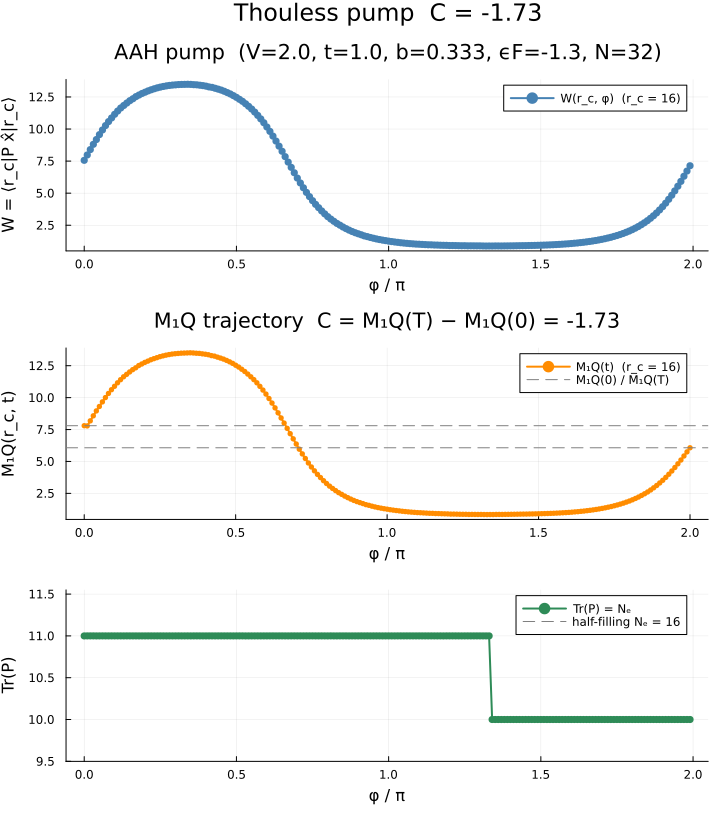

In [73]:
phi_axis      = phi_vals ./ π                              # Nt points ∈ [0, 2*(1-1/Nt))
phi_traj_axis = [k * dt_pump for k in 0:Nt_pump] ./ π    # Nt+1 points for M1Q trajectory

# ── Panel 1: local Wannier marker W(φ) ───────────────────────────────────────
p1 = plot(phi_axis, wannier;
     label="W(r_c, φ)  (r_c = $r_center)", lw=2, color=:steelblue,
     marker=:circle, ms=4, markerstrokewidth=0,
     xlabel="φ / π", ylabel="W = ⟨r_c|P x̂|r_c⟩",
     title="AAH pump  (V=$(V_pump), t=$(t_pump), b=$(round(b_pump;digits=3)), ϵF=$(ϵF_pump), N=$(N_pump))")

# ── Panel 2: M1Q(t) trajectory ───────────────────────────────────────────────
p2 = plot(phi_traj_axis, M1Q_traj;
     label="M₁Q(t)  (r_c = $r_center)", lw=2, color=:darkorange,
     marker=:circle, ms=3, markerstrokewidth=0,
     xlabel="φ / π", ylabel="M₁Q(r_c, t)",
     title="M₁Q trajectory  C = M₁Q(T) − M₁Q(0) = $(round(C_pump; digits=3))")
hline!(p2, [M1Q_traj[1], M1Q_traj[end]];
     ls=:dash, color=:gray, label="M₁Q(0) / M₁Q(T)")

# ── Panel 3: particle number Nₑ(φ) ───────────────────────────────────────────
p3 = plot(phi_axis, npart;
     label="Tr(P) = Nₑ", lw=2, color=:seagreen,
     marker=:circle, ms=4, markerstrokewidth=0,
     xlabel="φ / π", ylabel="Tr(P)",
     ylims=(minimum(npart) * 0.95, maximum(npart) * 1.05))
hline!(p3, [Ne_pump]; ls=:dash, color=:gray, label="half-filling Nₑ = $Ne_pump")

display(plot(p1, p2, p3;
     layout=(3, 1), size=(720, 820),
     plot_title="Thouless pump  C = $(round(C_pump; digits=3))"))